# Inference Notebook – Aplicación de Artefactos en Producción
Este notebook carga un modelo previamente entrenado y aplica scoring a datos OOT utilizando los artefactos guardados.

Autor: Josef Rodríguez

## 1. Importar librerías

In [46]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import json


## 2. Cargar dataset desde el repositorio

In [47]:

url = "https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/credit_dataset_temporal.csv"

df = pd.read_csv(url)

df.head()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,dataset,fecha_simulada,periodo
0,1,1.0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,train,2018-01-01 00:00:00,201801
1,2,0.0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,train,2018-01-01 01:00:00,201801
2,3,0.0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,train,2018-01-01 02:00:00,201801
3,4,0.0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,train,2018-01-01 03:00:00,201801
4,5,0.0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,train,2018-01-01 04:00:00,201801


## 3. Reconstruir variable temporal utilizada en el entrenamiento

In [48]:
n = len(df)
months = pd.date_range(start="2018-01-01", periods=60, freq="MS")

df["fecha_simulada"] = np.tile(months, int(np.ceil(n/60)))[:n]
df["periodo"] = df["fecha_simulada"].dt.strftime("%Y%m").astype(int)

In [49]:
records_period = df.groupby("periodo").size().reset_index(name="n_registros")

records_period

,periodo,n_registros
0,201801,4192
1,201802,4192
2,201803,4192
3,201804,4192
4,201805,4192
5,201806,4192
6,201807,4192
7,201808,4192
8,201809,4192
9,201810,4192


## 4. Filtrar datos Out Of Time (OOT)

In [50]:

oot = df[df.periodo == 202112]

In [51]:
records_period = oot.groupby("periodo").size().reset_index(name="n_registros")

records_period

,periodo,n_registros
0,202112,4191


## 5. Cargar artefactos del modelo

In [52]:

model = joblib.load("artifacts/model.pkl")
pipeline = joblib.load("artifacts/pipeline.pkl")


## 6. Cargar lista de variables del modelo

In [53]:

with open("artifacts/features.json") as f:
    features = json.load(f)

features


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

## 7. Cargar bins de score

In [54]:

with open("artifacts/score_bins.json") as f:
    bins = json.load(f)

bins


[-inf,
 0.008530982426629865,
 0.015045721685989147,
 0.030829256763003857,
 0.08089747298788506,
 inf]

## 8. Preparar datos para scoring

In [55]:

X = oot[features]


## 9. Aplicar pipeline de transformación

In [56]:

X_t = pipeline.transform(X)


## 10. Generar score de riesgo

In [57]:

oot["score"] = model.predict_proba(X_t)[:,1]

oot.head()


/Users/josefrodriguez/repos/ML_course/clases_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,dataset,fecha_simulada,periodo,score
47,48,0.0,0.140111,31,0,0.689370,1937.0,4,0,2,0,0.0,train,2021-12-01,202112,0.024414
107,108,0.0,0.635415,32,0,0.519494,3000.0,4,0,1,0,1.0,train,2021-12-01,202112,0.071192
167,168,0.0,0.020966,29,0,639.500000,1.0,3,0,1,0,2.0,train,2021-12-01,202112,0.007255
227,228,0.0,0.181557,36,0,0.560720,2000.0,7,0,1,0,1.0,train,2021-12-01,202112,0.023349
287,288,0.0,1.000000,62,0,0.000000,5480.0,3,0,0,0,0.0,train,2021-12-01,202112,0.022357


## 11. Crear bandas de riesgo

In [58]:

labels = ["Muy bajo","Bajo","Medio","Alto","Muy alto"]

oot["risk_band"] = pd.cut(
    oot["score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


## 12. Distribución del score

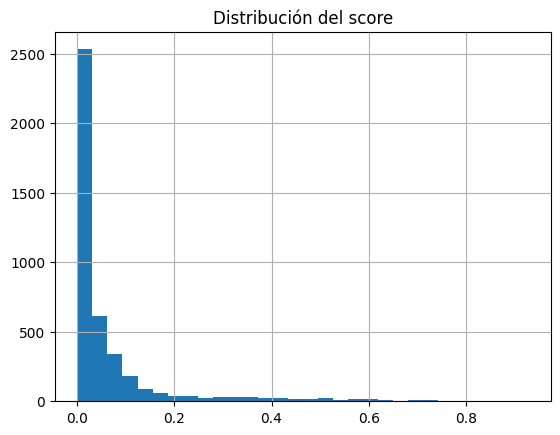

In [59]:

oot["score"].hist(bins=30)

plt.title("Distribución del score")
plt.show()


## 13. Distribución por bandas de riesgo

In [60]:

oot["risk_band"].value_counts()


risk_band
Muy bajo    889
Alto        864
Medio       844
Muy alto    837
Bajo        757
Name: count, dtype: int64

## 14. Default rate por banda

In [61]:

oot.groupby("risk_band")["SeriousDlqin2yrs"].mean()


risk_band
Muy bajo    0.003610
Bajo        0.009132
Medio       0.021696
Alto        0.055877
Muy alto    0.240664
Name: SeriousDlqin2yrs, dtype: float64

## 15. Tabla resumen por banda

In [62]:

summary_oot = (
    oot
    .groupby("risk_band")
    .agg(
        n_obs=("score","count"),
        n_bad=("SeriousDlqin2yrs","sum"),
        bad_rate=("SeriousDlqin2yrs","mean"),
        avg_score=("score","mean")
    )
)

summary_oot = summary_oot.loc[
    ["Muy alto","Alto","Medio","Bajo","Muy bajo"]
]

summary_oot


,n_obs,n_bad,bad_rate,avg_score
risk_band,,,,
Muy alto,837,116.0,0.240664,0.244589
Alto,864,29.0,0.055877,0.051489
Medio,844,11.0,0.021696,0.021108
Bajo,757,4.0,0.009132,0.011636
Muy bajo,889,2.0,0.003610,0.005996


## 16. Evolución del score por periodo

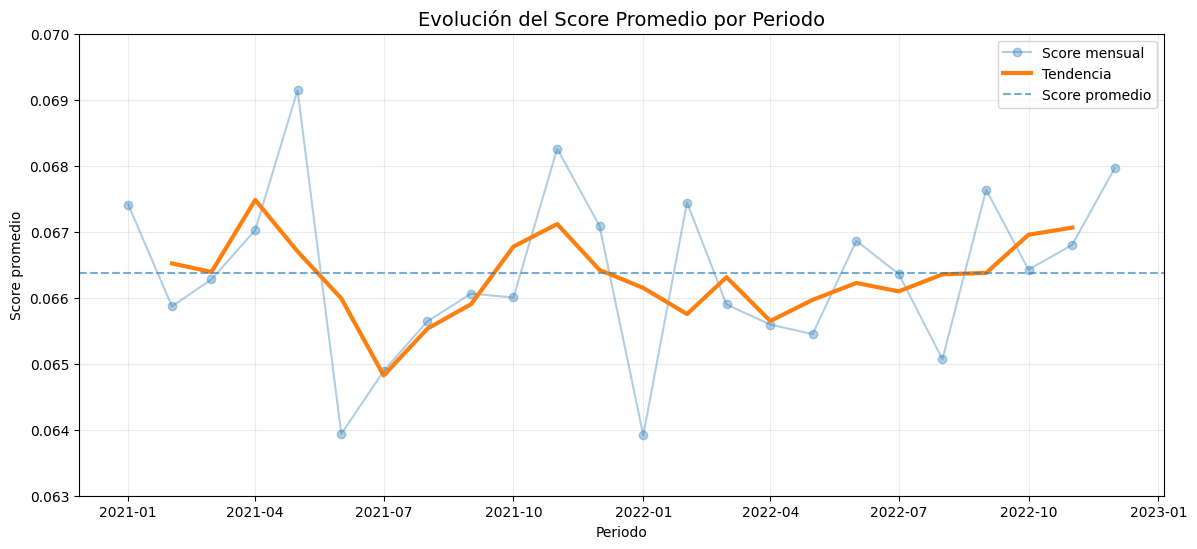

In [63]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

plt.figure(figsize=(14,6))

plt.plot(
    score_period["periodo"],
    score_period["score"],
    marker="o",
    alpha=0.35,
    label="Score mensual"
)

plt.plot(
    score_period["periodo"],
    score_period["score_smooth"],
    linewidth=3,
    label="Tendencia"
)

# límites del eje Y
plt.ylim(0.063, 0.070)

# ticks más limpios
plt.gca().yaxis.set_major_locator(MultipleLocator(0.001))

# formato de decimales
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))

# línea promedio
mean_score = score_period["score"].mean()
plt.axhline(mean_score, linestyle="--", alpha=0.6, label="Score promedio")

plt.title("Evolución del Score Promedio por Periodo", fontsize=14)

plt.xlabel("Periodo")
plt.ylabel("Score promedio")

plt.grid(alpha=0.25)

plt.legend()

plt.show()

In [67]:
oot[ ['periodo','Unnamed: 0','score','risk_band']].head(20)

,periodo,Unnamed: 0,score,risk_band
47,202112,48,0.024414,Medio
107,202112,108,0.071192,Alto
167,202112,168,0.007255,Muy bajo
227,202112,228,0.023349,Medio
287,202112,288,0.022357,Medio
347,202112,348,0.015197,Medio
407,202112,408,0.027063,Medio
467,202112,468,0.009219,Bajo
527,202112,528,0.213819,Muy alto
587,202112,588,0.206901,Muy alto


## 17. Conclusión
Este notebook demuestra cómo aplicar un modelo previamente entrenado utilizando artefactos guardados para simular un flujo de producción.

Flujo:
1. Cargar datos nuevos
2. Cargar artefactos del modelo
3. Aplicar transformaciones
4. Generar score
5. Clasificar riesgo